# 计算干静力稳定性 (Calculate Dry Static Stability)

计算热带海洋上空的干静力稳定性 N² 垂直廓线

**计算公式：**
$$N^2 = \frac{g}{\theta} \frac{\partial \theta}{\partial z}$$

其中：
- $g = 9.81$ m/s² 为重力加速度
- $\theta$ 为位温 (Potential Temperature)
- $z$ 为几何高度

计算结果将保存到 `fig12/` 目录

In [6]:
# 导入必要的库
import xarray as xr
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
from pathlib import Path
import os, gc
import matplotlib.pyplot as plt
# 设置路径
data_path = Path('/work/mh1498/m301257/3D_data')
output_dir = Path('/work/mh1498/m301257/Plot_data/fig12/')
output_dir.mkdir(exist_ok=True, parents=True)

# 物理常数
G = 9.81  # m/s²
TROPICAL_BOUNDS = (-16, 16)  # 热带区域纬度范围

print("✓ 库导入完成")
print(f"✓ 输出目录: {output_dir}")

✓ 库导入完成
✓ 输出目录: /work/mh1498/m301257/Plot_data/fig12


## 1. 数据读取

In [7]:
print("读取数据...")
chunksize=500
# 温度数据
ta_cntl = xr.open_dataset(data_path / 'cntl/ta_all_levels.nc', chunks={'time': chunksize})['ta']
ta_p4k = xr.open_dataset(data_path / 'p4k/ta_all_levels.nc', chunks={'time': chunksize})['ta']
ta_4co2 = xr.open_dataset(data_path / '4co2/ta_all_levels.nc', chunks={'time': chunksize})['ta']

# 位势高度数据
zg_cntl = xr.open_dataset(data_path / 'zg_2deg_interp_cntl.nc', chunks={'time': chunksize})['zg']
zg_p4k = xr.open_dataset(data_path / 'zg_2deg_interp_p4k.nc', chunks={'time': chunksize})['zg']
zg_4co2 = xr.open_dataset(data_path / 'zg_2deg_interp_4co2.nc', chunks={'time': chunksize})['zg']

# 压力数据
pre_cntl = xr.open_dataset(data_path / 'cntl/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']
pre_p4k = xr.open_dataset(data_path / 'p4k/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']
pre_4co2 = xr.open_dataset(data_path / '4co2/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']

print(f"✓ 数据读取完成")
print(f"  温度数据维度: {ta_cntl.dims}")
print(f"  高度数据维度: {zg_cntl.dims}")
print(f"  压力数据维度: {pre_cntl.dims}")

读取数据...
✓ 数据读取完成
  温度数据维度: ('level', 'time', 'lat', 'lon')
  高度数据维度: ('level_full', 'lat', 'lon')
  压力数据维度: ('level', 'time', 'lat', 'lon')


## 2. 数据预处理 - 热带海洋平均

✓ 维度名称: lat=lat, lon=lon, lev=level, time=time

数据维度检查:
  ta_cntl:  ('level', 'time', 'lat', 'lon')
  pre_cntl: ('level', 'time', 'lat', 'lon')
  zg_cntl:  ('level_full', 'lat', 'lon')

✓ 海洋掩膜加载完成: (15, 180)

应用热带海洋掩膜...
✓ 热带海洋区域选择完成
  ta 形状:  (22, 5114, 15, 180)
  pre 形状: (22, 5114, 15, 180)
  zg 形状:  (22, 15, 180)


5350

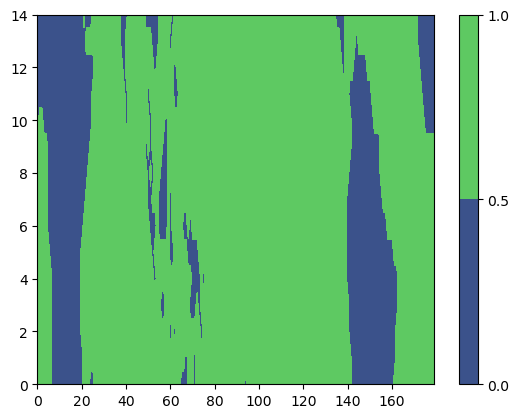

In [8]:
# 检测维度名称
def detect_dims(da):
    """自动检测数据维度名称"""
    lat_dim = [d for d in da.dims if d in ['lat', 'latitude', 'LAT']][0]
    lon_dim = [d for d in da.dims if d in ['lon', 'longitude', 'LON']][0]
    lev_dim = [d for d in da.dims if 'lev' in d.lower()][0]
    time_dim = [d for d in da.dims if 'time' in d.lower()]
    time_dim = time_dim[0] if time_dim else None
    return lat_dim, lon_dim, lev_dim, time_dim

lat_dim, lon_dim, lev_dim, time_dim = detect_dims(ta_cntl)
print(f"✓ 维度名称: lat={lat_dim}, lon={lon_dim}, lev={lev_dim}, time={time_dim}")

# 检查各数据集的维度
print(f"\n数据维度检查:")
print(f"  ta_cntl:  {ta_cntl.dims}")
print(f"  pre_cntl: {pre_cntl.dims}")
print(f"  zg_cntl:  {zg_cntl.dims}")

# 读取海洋掩膜
def load_ocean_mask():
    land_mask = xr.open_dataset('/work/mh1498/m301257/Plot_data/fig07/ocean_mask_2deg.nc')
    ocean_mask = land_mask['__xarray_dataarray_variable__'] == 1  # 海洋为True
    return ocean_mask

ocean_mask = load_ocean_mask()
plt.contourf(ocean_mask)  
plt.colorbar()  
print(f"\n✓ 海洋掩膜加载完成: {ocean_mask.shape}")

# 热带区域选择和掩膜应用
def select_tropical_ocean(da, lat_dim_name, ocean_mask_2d):
    """选择热带海洋区域"""
    # 选择热带纬度
    da_tropical = da.sel({lat_dim_name: slice(*TROPICAL_BOUNDS)})
    # 应用海洋掩膜 - 确保掩膜的维度顺序匹配
    # 掩膜只有 (lat, lon)，需要广播到数据的维度
    da_tropical = da_tropical.where(ocean_mask_2d)
    return da_tropical

print(f"\n应用热带海洋掩膜...")
ta_cntl_ocean = select_tropical_ocean(ta_cntl, lat_dim, ocean_mask)
ta_p4k_ocean = select_tropical_ocean(ta_p4k, lat_dim, ocean_mask)
ta_4co2_ocean = select_tropical_ocean(ta_4co2, lat_dim, ocean_mask)

pre_cntl_ocean = select_tropical_ocean(pre_cntl, lat_dim, ocean_mask)
pre_p4k_ocean = select_tropical_ocean(pre_p4k, lat_dim, ocean_mask)
pre_4co2_ocean = select_tropical_ocean(pre_4co2, lat_dim, ocean_mask)

zg_cntl_ocean = select_tropical_ocean(zg_cntl, lat_dim, ocean_mask)
zg_p4k_ocean = select_tropical_ocean(zg_p4k, lat_dim, ocean_mask)
zg_4co2_ocean = select_tropical_ocean(zg_4co2, lat_dim, ocean_mask)

print(f"✓ 热带海洋区域选择完成")
print(f"  ta 形状:  {ta_cntl_ocean.shape}")
print(f"  pre 形状: {pre_cntl_ocean.shape}")
print(f"  zg 形状:  {zg_cntl_ocean.shape}")
del ta_cntl, ta_p4k, ta_4co2
del pre_cntl, pre_p4k, pre_4co2
del zg_cntl, zg_p4k, zg_4co2
gc.collect()

## 3. 计算位温 (Potential Temperature)

### ⚠️ MetPy 单位处理说明

**问题**: MetPy 的 `potential_temperature` 函数返回带单位的 Pint Quantity 对象，需要正确提取数值。

**解决方案**: 
- 使用 `.magnitude` 属性提取数值部分
- 或者检查返回类型后相应处理

**原始错误**: `AttributeError: 'numpy.ndarray' object has no attribute 'units'`
**已修复**: ✓

### 📝 关于 MetPy 单位系统

MetPy 使用 **Pint** 库来处理物理单位，这是一个强大的特性，但需要正确处理：

1. **输入**: 需要显式指定单位
   ```python
   pressure * units.Pa
   temperature * units.K
   ```

2. **输出**: 返回带单位的对象 (Pint Quantity)
   - 包含数值 (`.magnitude`) 和单位 (`.units`)
   - 转换为 xarray 时需要提取数值部分

3. **优势**:
   - 自动单位转换
   - 防止单位错误
   - 物理量纲检查

4. **注意事项**:
   - xarray 原生不支持 Pint 单位（需要额外的 pint-xarray 包）
   - 本代码中手动提取数值并在 attrs 中记录单位

In [9]:
print("步骤1: 计算每个格点、每个时间的位温...")
print("  使用分块计算避免内存溢出...")

def calculate_potential_temperature_chunked(pressure_3d, temperature_3d):
    """
    使用分块方式计算3D位温场（避免内存溢出）
    
    参数:
        pressure_3d: 压力场 (Pa), dask array
        temperature_3d: 温度场 (K), dask array
    
    返回:
        theta_3d: 位温场 (K), dask array
    """
    # 确保数据维度一致
    if pressure_3d.dims != temperature_3d.dims:
        print(f"    警告: 维度不匹配!")
        print(f"      pressure dims: {pressure_3d.dims}")
        print(f"      temperature dims: {temperature_3d.dims}")
        # 尝试对齐维度
        if set(pressure_3d.dims) == set(temperature_3d.dims):
            # 维度相同但顺序不同，转置
            temperature_3d = temperature_3d.transpose(*pressure_3d.dims)
            print(f"      已转置temperature维度为: {temperature_3d.dims}")
    
    # 使用xarray的广播机制来处理维度对齐
    # MetPy会自动处理单位
    theta = mpcalc.potential_temperature(
        pressure_3d * units.Pa,
        temperature_3d * units.K
    )
    print(f"    位温计算完成，结果维度: {theta.dims}")
    print(f"    结果形状: {theta.shape}")
    
    # 检查 MetPy 返回的单位
    if hasattr(theta, 'units'):
        print(f"    位温单位: {theta.units}")
    
    # 转换回无单位的xarray DataArray
    # MetPy 返回的是带单位的 pint 数组，需要提取数值
    if hasattr(theta, 'magnitude'):
        # 如果是 pint Quantity，提取数值部分
        theta_values = theta.magnitude
    else:
        # 如果已经是数值，直接使用
        theta_values = theta
    
    theta_da = xr.DataArray(
        theta_values,
        coords=temperature_3d.coords,
        dims=temperature_3d.dims,
        attrs={'long_name': 'Potential Temperature', 'units': 'K'}
    )
    
    return theta_da

# 计算3D位温场（使用dask延迟计算）
print("  准备计算 CNTL 位温...")
theta_cntl_3d = calculate_potential_temperature_chunked(pre_cntl_ocean, ta_cntl_ocean)

print("  准备计算 P4K 位温...")
theta_p4k_3d = calculate_potential_temperature_chunked(pre_p4k_ocean, ta_p4k_ocean)

print("  准备计算 4CO2 位温...")
theta_4co2_3d = calculate_potential_temperature_chunked(pre_4co2_ocean, ta_4co2_ocean)

print(f"✓ 3D位温场准备完成（延迟计算）")
print(f"  CNTL  θ 形状: {theta_cntl_3d.shape}")

print(f"\n步骤2: 计算热带海洋时空平均廓线...")
print("  这一步会触发实际计算，可能需要一些时间...")

# 确定需要平均的维度
avg_dims = [time_dim, lat_dim, lon_dim] if time_dim else [lat_dim, lon_dim]
print(f"  平均维度: {avg_dims}")


步骤1: 计算每个格点、每个时间的位温...
  使用分块计算避免内存溢出...
  准备计算 CNTL 位温...
    位温计算完成，结果维度: ('level', 'time', 'lat', 'lon')
    结果形状: (22, 5114, 15, 180)
  准备计算 P4K 位温...
    位温计算完成，结果维度: ('level', 'time', 'lat', 'lon')
    结果形状: (22, 5114, 15, 180)
  准备计算 4CO2 位温...
    位温计算完成，结果维度: ('level', 'time', 'lat', 'lon')
    结果形状: (22, 5114, 15, 180)
✓ 3D位温场准备完成（延迟计算）
  CNTL  θ 形状: (22, 5114, 15, 180)

步骤2: 计算热带海洋时空平均廓线...
  这一步会触发实际计算，可能需要一些时间...
  平均维度: ['time', 'lat', 'lon']


## 4. 计算干静力稳定性 (Dry Static Stability)

In [10]:
newlevel = zg_cntl_ocean.mean(['lat','lon']).values
theta_cntl_3d=theta_cntl_3d.assign_coords({lev_dim: newlevel})
theta_p4k_3d=theta_p4k_3d.assign_coords({lev_dim: newlevel})
theta_4co2_3d=theta_4co2_3d.assign_coords({lev_dim: newlevel})

gc.collect()

5142

In [11]:
# ============================================================================
# ⚠️ 关键检查: 确认高度数据的单位
# ============================================================================

print("\n" + "="*70)
print("检查高度数据 (zg) 的单位和数值范围")
print("="*70)

# 检查原始数据的属性
print("\n1. 原始 zg 数据信息:")
print(f"   变量名: zg")
if hasattr(zg_cntl_ocean, 'units'):
    print(f"   单位属性: {zg_cntl_ocean.units}")
if hasattr(zg_cntl_ocean, 'long_name'):
    print(f"   长名称: {zg_cntl_ocean.long_name}")

# 检查数值范围
zg_min = float(zg_cntl_ocean.min())
zg_max = float(zg_cntl_ocean.max())
print(f"\n2. 数值范围:")
print(f"   最小值: {zg_min:.2f}")
print(f"   最大值: {zg_max:.2f}")

# 判断单位
print(f"\n3. 单位判断:")
if zg_max > 50000:  # > 50 km 说明可能是 Pa
    print(f"   ⚠️ 警告: 数值很大({zg_max:.0f})，可能是压力单位(Pa)")
    print(f"   建议检查数据!")
elif zg_max > 100:  # > 100 说明可能是 m 或 gpm
    print(f"   ✓ 数值范围合理 (0-{zg_max:.0f})")
    if zg_max > 50000:
        print(f"   可能单位: m (米)")
    else:
        print(f"   可能单位: m 或 gpm (位势米)")
        print(f"   注: gpm 和 m 在数值上非常接近，可直接使用")
else:
    print(f"   ⚠️ 警告: 数值太小({zg_max:.2f})，请检查单位")

# 计算平均高度廓线
newlevel = zg_cntl_ocean.mean(['lat','lon']).values
print(f"\n4. 平均高度廓线 (newlevel):")
print(f"   形状: {newlevel.shape}")
print(f"   范围: {newlevel.min():.1f} - {newlevel.max():.1f}")
print(f"   底层高度: {newlevel[0]:.1f}")
print(f"   顶层高度: {newlevel[-1]:.1f}")

# 检查垂直分辨率
if len(newlevel) > 1:
    dz_typical = np.median(np.diff(newlevel))
    print(f"   典型层厚: {dz_typical:.1f}")

print(f"\n{'='*70}")
print(f"✓ 高度数据检查完成")
print(f"  将使用 newlevel 作为垂直坐标计算 dθ/dz")
print(f"{'='*70}\n")


检查高度数据 (zg) 的单位和数值范围

1. 原始 zg 数据信息:
   变量名: zg

2. 数值范围:
   最小值: 12.50
   最大值: 22864.41

3. 单位判断:
   ✓ 数值范围合理 (0-22864)
   可能单位: m 或 gpm (位势米)
   注: gpm 和 m 在数值上非常接近，可直接使用

4. 平均高度廓线 (newlevel):
   形状: (22,)
   范围: 13.0 - 22864.4
   底层高度: 22864.4
   顶层高度: 13.0
   典型层厚: -947.7

✓ 高度数据检查完成
  将使用 newlevel 作为垂直坐标计算 dθ/dz



In [12]:
def calculate_static_stability(theta_3d, height_profile_m, lev_dim_name):
    """
    计算干静力稳定性 N² = (g/θ)(∂θ/∂z)
    
    参数:
        theta_3d: 位温场 (K) - 3D或4D数组 (time, lat, lon, lev)
        height_profile_m: 高度廓线 (m) - 1D数组
        lev_dim_name: 垂直维度名称
    
    返回:
        N2: Brunt-Väisälä 频率平方 (s⁻²)
        dtheta_dz: 位温垂直梯度 (K/m)
    """
    print(f"  计算位温场平均廓线...")
    # 先对空间和时间维度求平均，得到1D廓线
    avg_dims = [d for d in theta_3d.dims if d != lev_dim_name]
    theta_profile = theta_3d.mean(dim=avg_dims).compute()
    
    print(f"  计算垂直梯度...")
    # 计算 dθ/dz (单位: K/m)
    # 使用中心差分法 - 现在是1D数组运算
    dtheta = np.gradient(theta_profile.values)
    dz = np.gradient(height_profile_m)
    dtheta_dz = dtheta / dz
    
    # 计算 N² = (g/θ)(∂θ/∂z)
    N2 = (G / theta_profile.values) * dtheta_dz
    
    # 转换为 DataArray
    coords = {lev_dim_name: theta_profile[lev_dim_name]}
    
    N2_da = xr.DataArray(
        N2,
        coords=coords,
        dims=[lev_dim_name],
        attrs={
            'long_name': 'Brunt-Vaisala frequency squared (Dry Static Stability)',
            'units': 's^-2',
            'formula': 'N^2 = (g/theta) * d(theta)/dz'
        }
    )
    
    dtheta_dz_da = xr.DataArray(
        dtheta_dz,
        coords=coords,
        dims=[lev_dim_name],
        attrs={
            'long_name': 'Potential temperature vertical gradient',
            'units': 'K/m'
        }
    )
    
    return N2_da, dtheta_dz_da

print("步骤3: 计算干静力稳定性 N²...")
print("  这一步会先计算时空平均廓线，然后计算垂直梯度...")

# 计算各个试验的静力稳定性
print("\n  处理 CNTL...")
N2_cntl, dtheta_dz_cntl = calculate_static_stability(theta_cntl_3d, newlevel, lev_dim)

print("\n  处理 P4K...")
N2_p4k, dtheta_dz_p4k = calculate_static_stability(theta_p4k_3d, newlevel, lev_dim)

print("\n  处理 4CO2...")
N2_4co2, dtheta_dz_4co2 = calculate_static_stability(theta_4co2_3d, newlevel, lev_dim)


# 计算差异
print("\n  计算差异...")
N2_p4k_diff = N2_p4k - N2_cntl
N2_4co2_diff = N2_4co2 - N2_cntl
dtheta_dz_p4k_diff = dtheta_dz_p4k - dtheta_dz_cntl
dtheta_dz_4co2_diff = dtheta_dz_4co2 - dtheta_dz_cntl

print(f"\n✓ 干静力稳定性计算完成")


步骤3: 计算干静力稳定性 N²...
  这一步会先计算时空平均廓线，然后计算垂直梯度...

  处理 CNTL...
  计算位温场平均廓线...
  计算垂直梯度...

  处理 P4K...
  计算位温场平均廓线...
  计算垂直梯度...

  处理 P4K...
  计算位温场平均廓线...
  计算垂直梯度...

  处理 4CO2...
  计算位温场平均廓线...
  计算垂直梯度...

  处理 4CO2...
  计算位温场平均廓线...
  计算垂直梯度...

  计算差异...

✓ 干静力稳定性计算完成
  计算垂直梯度...

  计算差异...

✓ 干静力稳定性计算完成


## 5. 单位和量级验证 ✓

In [14]:
# ============================================================================
# 执行单位和量级验证
# ============================================================================
# ============================================================================
# 单位和量级验证函数
# ============================================================================

def validate_static_stability(N2, dtheta_dz, height, experiment_name):
    """
    验证干静力稳定性计算的单位和量级是否合理
    
    参数:
        N2: 静力稳定性 (s^-2)
        dtheta_dz: 位温梯度 (K/m)
        height: 高度 (m)
        experiment_name: 实验名称
    """
    print(f"\n{'='*70}")
    print(f"验证 {experiment_name} 的计算结果")
    print(f"{'='*70}")
    
    # 转换单位便于阅读
    N2_1e4 = N2 * 1e4  # 转换为 ×10⁻⁴ s⁻²
    dtheta_dz_km = dtheta_dz * 1000  # 转换为 K/km
    height_km = height / 1000  # 转换为 km
    
    # 统计信息
    print(f"\n1. 位温垂直梯度 dθ/dz:")
    print(f"   单位: K/m (显示为 K/km)")
    print(f"   最小值: {float(dtheta_dz_km.min()):8.3f} K/km")
    print(f"   最大值: {float(dtheta_dz_km.max()):8.3f} K/km")
    print(f"   平均值: {float(dtheta_dz_km.mean()):8.3f} K/km")
    print(f"   ✓ 预期范围: 3-15 K/km (对流层-平流层)")
    
    print(f"\n2. 干静力稳定性 N²:")
    print(f"   单位: s^-2 (显示为 ×10⁻⁴ s⁻²)")
    print(f"   最小值: {float(N2_1e4.min()):8.3f} × 10⁻⁴ s⁻²")
    print(f"   最大值: {float(N2_1e4.max()):8.3f} × 10⁻⁴ s⁻²")
    print(f"   平均值: {float(N2_1e4.mean()):8.3f} × 10⁻⁴ s⁻²")
    print(f"   ✓ 预期范围: 1-10 × 10⁻⁴ s⁻²")
    
    # 布伦特-维萨拉频率
    N = np.sqrt(np.abs(N2))
    print(f"\n3. 布伦特-维萨拉频率 N = √(N²):")
    print(f"   单位: s^-1")
    print(f"   平均值: {float(N.mean()):.5f} s⁻¹")
    print(f"   周期:   {float(2*np.pi/N.mean()):.1f} 秒")
    print(f"   ✓ 预期范围: 0.01-0.03 s⁻¹ (对流层)")
    
    # 检查不稳定层（N² < 0）
    unstable = N2 < 0
    if unstable.any():
        print(f"\n⚠️  警告: 发现 {int(unstable.sum())} 个不稳定层 (N² < 0)")
        print(f"   这在边界层或对流区域可能是正常的")
    
    # 垂直分层检查
    print(f"\n4. 垂直分层分析:")
    
    # 对流层 (0-10 km)
    trop_mask = height_km < 10
    if trop_mask.any():
        N2_trop_mean = float(N2_1e4[trop_mask].mean())
        dtheta_trop_mean = float(dtheta_dz_km[trop_mask].mean())
        print(f"   对流层 (0-10 km):")
        print(f"     N² = {N2_trop_mean:.3f} × 10⁻⁴ s⁻²")
        print(f"     dθ/dz = {dtheta_trop_mean:.3f} K/km")
        
        # 验证
        if 0.5 <= N2_trop_mean <= 5:
            print(f"     ✓ N² 在合理范围内")
        else:
            print(f"     ⚠️ N² 可能异常")
            
        if 2 <= dtheta_trop_mean <= 8:
            print(f"     ✓ dθ/dz 在合理范围内")
        else:
            print(f"     ⚠️ dθ/dz 可能异常")
    
    # 平流层 (10-30 km)
    strat_mask = (height_km >= 10) & (height_km < 30)
    if strat_mask.any():
        N2_strat_mean = float(N2_1e4[strat_mask].mean())
        dtheta_strat_mean = float(dtheta_dz_km[strat_mask].mean())
        print(f"\n   平流层 (10-30 km):")
        print(f"     N² = {N2_strat_mean:.3f} × 10⁻⁴ s⁻²")
        print(f"     dθ/dz = {dtheta_strat_mean:.3f} K/km")
        
        # 验证
        if 3 <= N2_strat_mean <= 15:
            print(f"     ✓ N² 在合理范围内")
        else:
            print(f"     ⚠️ N² 可能异常")
            
        if 5 <= dtheta_strat_mean <= 20:
            print(f"     ✓ dθ/dz 在合理范围内")
        else:
            print(f"     ⚠️ dθ/dz 可能异常")
    
    print(f"\n{'='*70}")
    
    return N2_1e4, dtheta_dz_km, height_km
print("\n\n" + "="*70)
print("开始验证计算结果的单位和量级...")
print("="*70)

# 验证三个实验
N2_cntl_scaled, dtheta_cntl_scaled, height_km = validate_static_stability(
    N2_cntl, dtheta_dz_cntl, newlevel, "CONTROL"
)

N2_p4k_scaled, dtheta_p4k_scaled, _ = validate_static_stability(
    N2_p4k, dtheta_dz_p4k, newlevel, "+4K SST"
)

N2_4co2_scaled, dtheta_4co2_scaled, _ = validate_static_stability(
    N2_4co2, dtheta_dz_4co2, newlevel, "4×CO₂"
)

print("\n" + "="*70)
print("✅ 验证完成！")
print("="*70)

# 清理大数组释放内存
del theta_cntl_3d, theta_p4k_3d, theta_4co2_3d
del ta_cntl_ocean, ta_p4k_ocean, ta_4co2_ocean
del pre_cntl_ocean, pre_p4k_ocean, pre_4co2_ocean
del zg_cntl_ocean, zg_p4k_ocean, zg_4co2_ocean
gc.collect()
print("\n✓ 内存清理完成")




开始验证计算结果的单位和量级...

验证 CONTROL 的计算结果

1. 位温垂直梯度 dθ/dz:
   单位: K/m (显示为 K/km)
   最小值:   -1.576 K/km
   最大值:   31.241 K/km
   平均值:    7.394 K/km
   ✓ 预期范围: 3-15 K/km (对流层-平流层)

2. 干静力稳定性 N²:
   单位: s^-2 (显示为 ×10⁻⁴ s⁻²)
   最小值:   -0.520 × 10⁻⁴ s⁻²
   最大值:    6.760 × 10⁻⁴ s⁻²
   平均值:    1.860 × 10⁻⁴ s⁻²
   ✓ 预期范围: 1-10 × 10⁻⁴ s⁻²

3. 布伦特-维萨拉频率 N = √(N²):
   单位: s^-1
   平均值: 0.01238 s⁻¹
   周期:   507.5 秒
   ✓ 预期范围: 0.01-0.03 s⁻¹ (对流层)

⚠️  警告: 发现 2 个不稳定层 (N² < 0)
   这在边界层或对流区域可能是正常的

4. 垂直分层分析:
   对流层 (0-10 km):
     N² = 1.033 × 10⁻⁴ s⁻²
     dθ/dz = 3.250 K/km
     ✓ N² 在合理范围内
     ✓ dθ/dz 在合理范围内

   平流层 (10-30 km):
     N² = 3.632 × 10⁻⁴ s⁻²
     dθ/dz = 16.275 K/km
     ✓ N² 在合理范围内
     ✓ dθ/dz 在合理范围内


验证 +4K SST 的计算结果

1. 位温垂直梯度 dθ/dz:
   单位: K/m (显示为 K/km)
   最小值:   -1.415 K/km
   最大值:   31.669 K/km
   平均值:    7.145 K/km
   ✓ 预期范围: 3-15 K/km (对流层-平流层)

2. 干静力稳定性 N²:
   单位: s^-2 (显示为 ×10⁻⁴ s⁻²)
   最小值:   -0.460 × 10⁻⁴ s⁻²
   最大值:    6.671 × 10⁻⁴ s⁻²
   平均值:    1.820 × 10⁻⁴ s⁻²
   ✓ 预期

In [16]:
print("\n保存计算结果...")

# 创建数据集
ds = xr.Dataset({
    
    # 位温垂直梯度 (K/m)
    'dtheta_dz_cntl': dtheta_dz_cntl,
    'dtheta_dz_p4k': dtheta_dz_p4k,
    'dtheta_dz_4co2': dtheta_dz_4co2,
    'dtheta_dz_p4k_diff': dtheta_dz_p4k_diff,
    'dtheta_dz_4co2_diff': dtheta_dz_4co2_diff,
    
    # 干静力稳定性 (s^-2)
    'N2_cntl': N2_cntl,
    'N2_p4k': N2_p4k,
    'N2_4co2': N2_4co2,
    'N2_p4k_diff': N2_p4k_diff,
    'N2_4co2_diff': N2_4co2_diff,
    
    # 高度廓线 (m)
    'height': (lev_dim, newlevel),
})

# 添加全局属性
ds.attrs = {
    'title': 'Dry Static Stability for Tropical Ocean',
    'description': 'Vertical profiles of potential temperature gradient and static stability',
    'region': f'Tropical Ocean ({TROPICAL_BOUNDS[0]}°-{TROPICAL_BOUNDS[1]}°)',
    'gravity': f'{G} m/s^2',
    'formula': 'N^2 = (g/theta) * d(theta)/dz',
    'method': 'Potential temperature calculated at each grid point first, then averaged over tropical ocean',
    'created': str(np.datetime64('now')),
}

# 保存为NetCDF文件
output_file = output_dir / 'dry_static_stability_data.nc'
ds.to_netcdf(output_file)




保存计算结果...
